# ML Layer: FIFA World Cup Match Outcome Prediction

This notebook trains and registers a **multi-class XGBoost classifier** to predict FIFA World Cup match outcomes (home_win / draw / away_win).

**Architecture:** Bronze → Silver → Gold → **ML Model** (this notebook)

**Features (from Feature Store):**
- Rolling team form (last 5/10 matches): win rate, avg goals, days rest
- Head-to-head historical record: total meetings, wins per side
- Designed with no data leakage (ROWS BETWEEN N PRECEDING AND 1 PRECEDING)

**Model:**
- Algorithm: XGBoost (`xgb.XGBClassifier`, multi:softprob)
- Split: Chronological (pre-2014 train, 2014+ test) — no temporal leakage
- Target: `home_result` encoded as {W: home_win, D: draw, L: away_win}
- Registry: `fifa_worldcup.match_prediction_dev.match_outcome_model` (Unity Catalog)

**Data Sources:**
- Feature view: `fifa_worldcup.match_prediction_dev.vw_match_prediction_features`
- Feature Store: `team_form_gold` (timeseries PK), `head_to_head_gold`

**Pipeline Job:** [FIFA Match Prediction - Full Pipeline](/#job/146142328218872)

In [0]:
%pip install xgboost databricks-feature-engineering --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

Dataset: 1248 rows, 20 columns
Date range: 1930-07-13 to 2022-12-18

Target distribution (home_result):
home_result
W    677
L    318
D    253
Name: count, dtype: int64

Class proportions:
home_result
W    0.542
L    0.255
D    0.203
Name: proportion, dtype: float64

Features (11): ['home_form_5_win_rate', 'home_form_10_win_rate', 'home_form_5_avg_goals', 'home_days_rest', 'away_form_5_win_rate', 'away_form_10_win_rate', 'away_form_5_avg_goals', 'away_days_rest', 'total_meetings', 'h2h_team1_wins', 'h2h_team2_wins']

Null counts in features:
home_form_5_win_rate     36
home_form_10_win_rate    36
home_form_5_avg_goals    36
home_days_rest           36
away_form_5_win_rate     52
away_form_10_win_rate    52
away_form_5_avg_goals    52
away_days_rest           52
total_meetings            0
h2h_team1_wins            0
h2h_team2_wins            0
dtype: int64


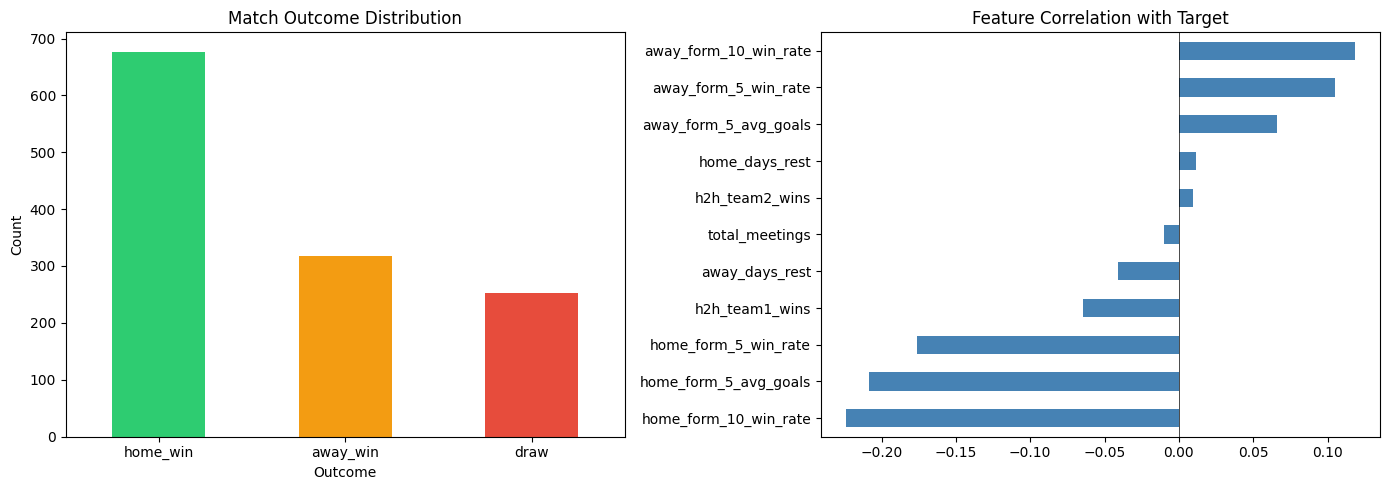

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, year

# --- Load feature view ---
df_spark = spark.table("fifa_worldcup.match_prediction_dev.vw_match_prediction_features")
df = df_spark.toPandas()

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date range: {df['match_date'].min()} to {df['match_date'].max()}")
print(f"\nTarget distribution (home_result):")
print(df['home_result'].value_counts())
print(f"\nClass proportions:")
print(df['home_result'].value_counts(normalize=True).round(3))

# --- Define features (EXCLUDE actual goals - that's the outcome!) ---
FEATURE_COLS = [
    'home_form_5_win_rate', 'home_form_10_win_rate', 'home_form_5_avg_goals', 'home_days_rest',
    'away_form_5_win_rate', 'away_form_10_win_rate', 'away_form_5_avg_goals', 'away_days_rest',
    'total_meetings', 'h2h_team1_wins', 'h2h_team2_wins',
]

TARGET_COL = 'home_result'

# --- Encode target ---
target_map = {'W': 'home_win', 'D': 'draw', 'L': 'away_win'}
df['target_label'] = df[TARGET_COL].map(target_map)
df['target_encoded'] = df['target_label'].map({'home_win': 0, 'draw': 1, 'away_win': 2})

print(f"\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"\nNull counts in features:")
print(df[FEATURE_COLS].isnull().sum())

# --- EDA: Feature correlations with target ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
df['target_label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Match Outcome Distribution')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Feature correlation with target
corr_with_target = df[FEATURE_COLS + ['target_encoded']].corr()['target_encoded'].drop('target_encoded')
corr_with_target.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Correlation with Target')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [0]:
# --- Chronological split: pre-2014 train, 2014+ test ---
# This prevents temporal leakage (model never sees future data during training)

df['match_year'] = pd.to_datetime(df['match_date']).dt.year

train_df = df[df['match_year'] < 2014].copy()
test_df = df[df['match_year'] >= 2014].copy()

# Handle nulls (early matches have no form history)
train_df = train_df.dropna(subset=FEATURE_COLS + ['target_encoded'])
test_df = test_df.dropna(subset=FEATURE_COLS + ['target_encoded'])

X_train = train_df[FEATURE_COLS].values
y_train = train_df['target_encoded'].values.astype(int)
X_test = test_df[FEATURE_COLS].values
y_test = test_df['target_encoded'].values.astype(int)

print(f"Train set: {X_train.shape[0]} matches (1930-2013)")
print(f"Test set:  {X_test.shape[0]} matches (2014-2022)")
print(f"\nTrain class distribution:")
print(pd.Series(y_train).map({0: 'home_win', 1: 'draw', 2: 'away_win'}).value_counts())
print(f"\nTest class distribution:")
print(pd.Series(y_test).map({0: 'home_win', 1: 'draw', 2: 'away_win'}).value_counts())

Train set: 878 matches (1930-2013)
Test set:  291 matches (2014-2022)

Train class distribution:
home_win    489
away_win    202
draw        187
Name: count, dtype: int64

Test class distribution:
home_win    134
away_win    102
draw         55
Name: count, dtype: int64


2026/07/16 03:33:31 INFO mlflow.tracking.fluent: Experiment with name '/Users/amar.rathour@thoughtworks.com/fifa_match_prediction' does not exist. Creating a new experiment.
/local_disk0/.ephemeral_nfs/envs/pythonEnv-7493075c-b4ce-405a-8878-1807114db983/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [03:33:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


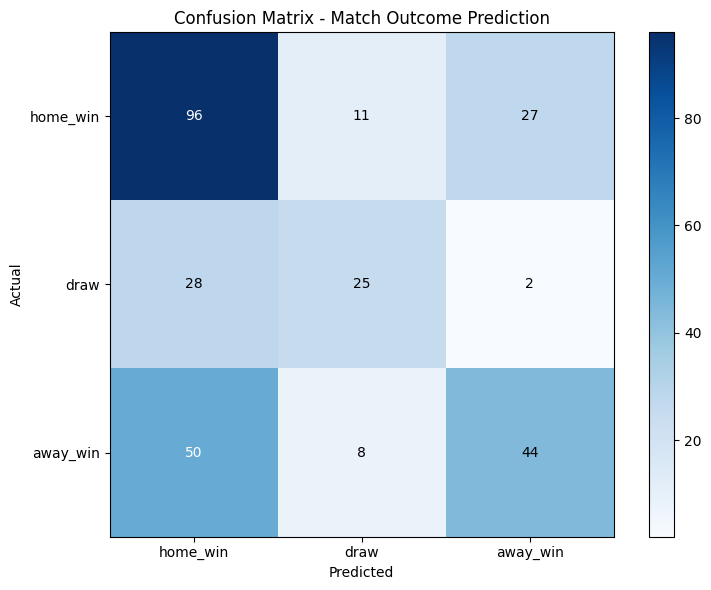

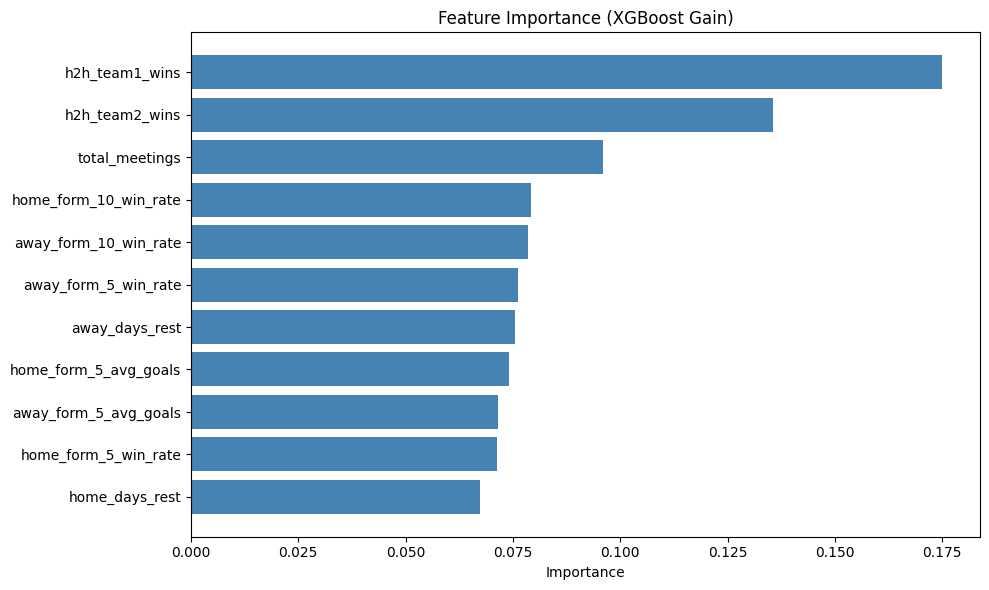

🔗 View Logged Model at: https://dbc-ba3cda01-8312.cloud.databricks.com/ml/experiments/2072517314088452/models/m-0e4463f50b1b4ffd8539220a62682c62?o=2464733314746848
Successfully registered model 'fifa_worldcup.match_prediction_dev.match_outcome_model'.


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '1' of model 'fifa_worldcup.match_prediction_dev.match_outcome_model': https://dbc-ba3cda01-8312.cloud.databricks.com/explore/data/models/fifa_worldcup/match_prediction_dev/match_outcome_model/version/1?o=2464733314746848


MODEL TRAINING COMPLETE

Accuracy: 0.5670
F1 (macro): 0.5438
F1 (weighted): 0.5588

Model registered: fifa_worldcup.match_prediction_dev.match_outcome_model
Model version: 1
MLflow run ID: 8358f3ce58d14b29b79b721d75227d35

--- Classification Report ---
              precision    recall  f1-score   support

    home_win       0.55      0.72      0.62       134
        draw       0.57      0.45      0.51        55
    away_win       0.60      0.43      0.50       102

    accuracy                           0.57       291
   macro avg       0.57      0.53      0.54       291
weighted avg       0.57      0.57      0.56       291



In [0]:
import xgboost as xgb
import mlflow
import mlflow.xgboost
from mlflow.models.signature import infer_signature
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# --- Model parameters ---
params = {
    'objective': 'multi:softprob',
    'num_class': 3,
    'max_depth': 5,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'random_state': 42,
    'eval_metric': 'mlogloss',
    'use_label_encoder': False,
}

# --- Set MLflow experiment ---
mlflow.set_registry_uri("databricks-uc")
experiment_name = "/Users/amar.rathour@thoughtworks.com/fifa_match_prediction"
mlflow.set_experiment(experiment_name)

# --- Train and log ---
with mlflow.start_run(run_name="xgboost_match_outcome_v1") as run:
    # Train
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    # Log parameters
    mlflow.log_params(params)
    mlflow.log_param("train_size", X_train.shape[0])
    mlflow.log_param("test_size", X_test.shape[0])
    mlflow.log_param("features", FEATURE_COLS)
    mlflow.log_param("split_strategy", "chronological_2014")
    
    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_macro", f1_macro)
    mlflow.log_metric("f1_weighted", f1_weighted)
    
    # Log confusion matrix
    class_names = ['home_win', 'draw', 'away_win']
    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    im = ax_cm.imshow(cm, interpolation='nearest', cmap='Blues')
    ax_cm.set_title('Confusion Matrix - Match Outcome Prediction')
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_xticks(range(3))
    ax_cm.set_yticks(range(3))
    ax_cm.set_xticklabels(class_names)
    ax_cm.set_yticklabels(class_names)
    for i in range(3):
        for j in range(3):
            ax_cm.text(j, i, str(cm[i, j]), ha='center', va='center',
                      color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.colorbar(im)
    plt.tight_layout()
    mlflow.log_figure(fig_cm, "confusion_matrix.png")
    plt.show()
    
    # Log feature importance
    importance = model.feature_importances_
    fig_fi, ax_fi = plt.subplots(figsize=(10, 6))
    sorted_idx = np.argsort(importance)
    ax_fi.barh(range(len(FEATURE_COLS)), importance[sorted_idx], color='steelblue')
    ax_fi.set_yticks(range(len(FEATURE_COLS)))
    ax_fi.set_yticklabels([FEATURE_COLS[i] for i in sorted_idx])
    ax_fi.set_title('Feature Importance (XGBoost Gain)')
    ax_fi.set_xlabel('Importance')
    plt.tight_layout()
    mlflow.log_figure(fig_fi, "feature_importance.png")
    plt.show()
    
    # Register model in Unity Catalog
    registered_model_name = "fifa_worldcup.match_prediction_dev.match_outcome_model"
    X_train_df = pd.DataFrame(X_train, columns=FEATURE_COLS)
    signature = infer_signature(X_train_df, model.predict(X_train))
    
    model_info = mlflow.xgboost.log_model(
        model,
        name="model",
        signature=signature,
        input_example=X_train_df.head(3),
        registered_model_name=registered_model_name,
    )
    
    # Tag the run
    mlflow.set_tag("pipeline", "fifa_match_prediction")
    mlflow.set_tag("layer", "ml_model")
    mlflow.set_tag("catalog", "fifa_worldcup")
    
    print("=" * 60)
    print("MODEL TRAINING COMPLETE")
    print("=" * 60)
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"F1 (macro): {f1_macro:.4f}")
    print(f"F1 (weighted): {f1_weighted:.4f}")
    print(f"\nModel registered: {registered_model_name}")
    print(f"Model version: {model_info.registered_model_version}")
    print(f"MLflow run ID: {run.info.run_id}")
    print(f"\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=class_names))

In [0]:
%pip install optuna --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


Starting Optuna hyperparameter search (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


✅ Optuna search complete!
   Best F1 (macro): 0.5799
   Best params: {'max_depth': 4, 'learning_rate': 0.07698026785529695, 'n_estimators': 500, 'subsample': 0.7768582936536825, 'colsample_bytree': 0.9183520991892179, 'min_child_weight': 4, 'gamma': 0.467944125803584, 'reg_alpha': 6.423773618358698e-06, 'reg_lambda': 3.8720262560550486e-05}


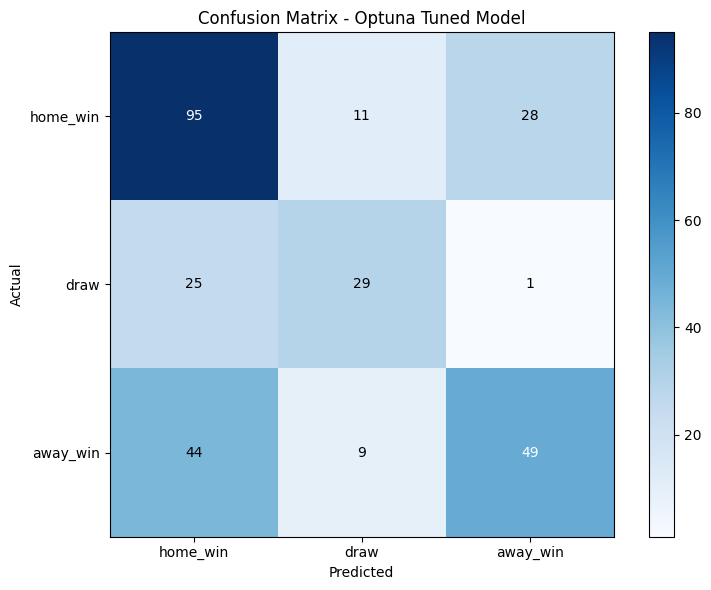

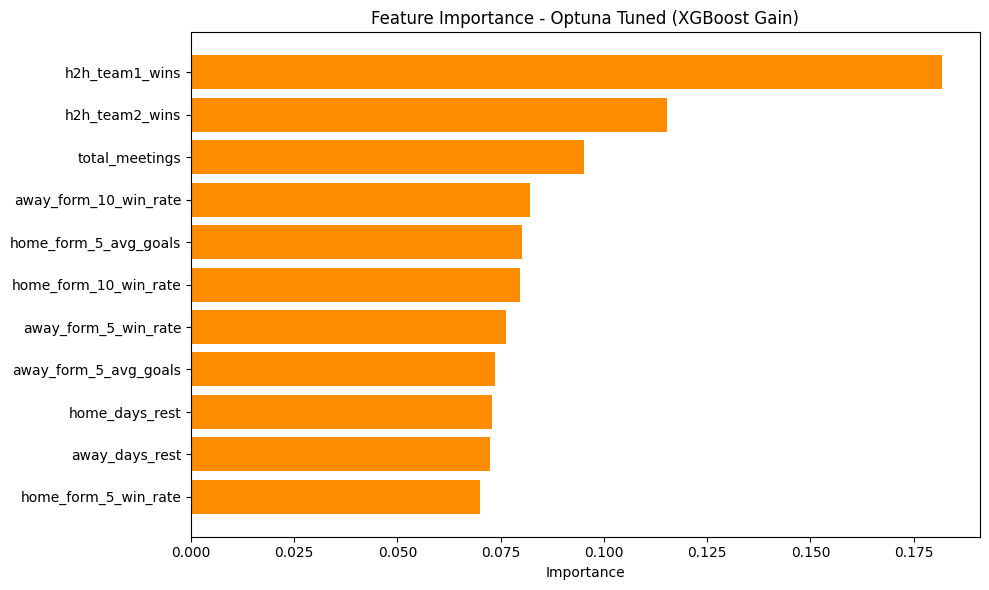

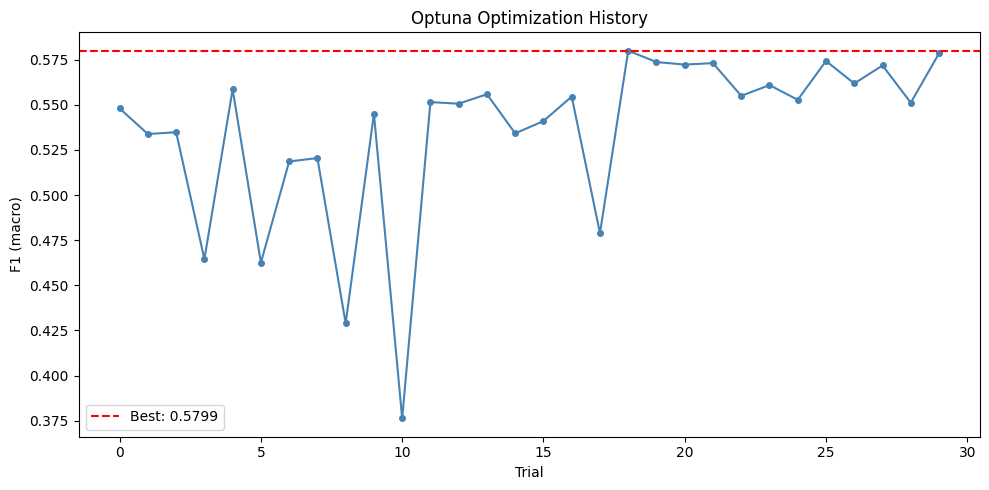

🔗 View Logged Model at: https://dbc-ba3cda01-8312.cloud.databricks.com/ml/experiments/2072517314088452/models/m-bb2863fea9e948d49de8fbe52690560b?o=2464733314746848
Registered model 'fifa_worldcup.match_prediction_dev.match_outcome_model' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '2' of model 'fifa_worldcup.match_prediction_dev.match_outcome_model': https://dbc-ba3cda01-8312.cloud.databricks.com/explore/data/models/fifa_worldcup/match_prediction_dev/match_outcome_model/version/2?o=2464733314746848



OPTUNA-TUNED MODEL REGISTERED

  v1 (baseline):     F1=0.5438 | Acc=0.5670
  v2 (optuna tuned): F1=0.5799 | Acc=0.5945
  Improvement: +6.6% F1 (macro)

  Model: fifa_worldcup.match_prediction_dev.match_outcome_model (version 2)
  MLflow run: 23beced080194c869c964fd8a543e485

--- Classification Report (Tuned) ---
              precision    recall  f1-score   support

    home_win       0.58      0.71      0.64       134
        draw       0.59      0.53      0.56        55
    away_win       0.63      0.48      0.54       102

    accuracy                           0.59       291
   macro avg       0.60      0.57      0.58       291
weighted avg       0.60      0.59      0.59       291



In [0]:
import optuna
import xgboost as xgb
import mlflow
import mlflow.xgboost
from mlflow.models.signature import infer_signature
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

mlflow.set_registry_uri("databricks-uc")
experiment_name = "/Users/amar.rathour@thoughtworks.com/fifa_match_prediction"
mlflow.set_experiment(experiment_name)

# --- Optuna objective function ---
def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'eval_metric': 'mlogloss',
    }
    
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred, average='macro')

# --- Run Optuna study ---
print("Starting Optuna hyperparameter search (30 trials)...")
print("=" * 60)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize', study_name='fifa_xgboost_tuning')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n\u2705 Optuna search complete!")
print(f"   Best F1 (macro): {study.best_value:.4f}")
print(f"   Best params: {study.best_params}")

# --- Train final model with best params ---
best_params = study.best_params
best_params.update({'objective': 'multi:softprob', 'num_class': 3, 'random_state': 42, 'eval_metric': 'mlogloss'})

best_model = xgb.XGBClassifier(**best_params)
best_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
f1_macro_best = f1_score(y_test, y_pred_best, average='macro')
f1_weighted_best = f1_score(y_test, y_pred_best, average='weighted')

# --- Log best model to MLflow ---
class_names = ['home_win', 'draw', 'away_win']
FEATURE_COLS = [
    'home_form_5_win_rate', 'home_form_10_win_rate', 'home_form_5_avg_goals', 'home_days_rest',
    'away_form_5_win_rate', 'away_form_10_win_rate', 'away_form_5_avg_goals', 'away_days_rest',
    'total_meetings', 'h2h_team1_wins', 'h2h_team2_wins',
]

with mlflow.start_run(run_name="xgboost_optuna_tuned_v2") as run:
    mlflow.log_params(best_params)
    mlflow.log_param("tuning_method", "optuna")
    mlflow.log_param("n_trials", 30)
    mlflow.log_param("train_size", X_train.shape[0])
    mlflow.log_param("test_size", X_test.shape[0])
    mlflow.log_param("split_strategy", "chronological_2014")
    
    mlflow.log_metric("accuracy", acc_best)
    mlflow.log_metric("f1_macro", f1_macro_best)
    mlflow.log_metric("f1_weighted", f1_weighted_best)
    mlflow.log_metric("optuna_best_trial", study.best_trial.number)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred_best)
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    im = ax_cm.imshow(cm, interpolation='nearest', cmap='Blues')
    ax_cm.set_title('Confusion Matrix - Optuna Tuned Model')
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_xticks(range(3))
    ax_cm.set_yticks(range(3))
    ax_cm.set_xticklabels(class_names)
    ax_cm.set_yticklabels(class_names)
    for i in range(3):
        for j in range(3):
            ax_cm.text(j, i, str(cm[i, j]), ha='center', va='center',
                      color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.colorbar(im)
    plt.tight_layout()
    mlflow.log_figure(fig_cm, "confusion_matrix_tuned.png")
    plt.show()
    
    # Feature importance
    importance = best_model.feature_importances_
    fig_fi, ax_fi = plt.subplots(figsize=(10, 6))
    sorted_idx = np.argsort(importance)
    ax_fi.barh(range(len(FEATURE_COLS)), importance[sorted_idx], color='darkorange')
    ax_fi.set_yticks(range(len(FEATURE_COLS)))
    ax_fi.set_yticklabels([FEATURE_COLS[i] for i in sorted_idx])
    ax_fi.set_title('Feature Importance - Optuna Tuned (XGBoost Gain)')
    ax_fi.set_xlabel('Importance')
    plt.tight_layout()
    mlflow.log_figure(fig_fi, "feature_importance_tuned.png")
    plt.show()
    
    # Optuna optimization history
    fig_opt, ax_opt = plt.subplots(figsize=(10, 5))
    trials = [t.value for t in study.trials]
    ax_opt.plot(range(len(trials)), trials, 'o-', color='steelblue', markersize=4)
    ax_opt.axhline(y=study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
    ax_opt.set_xlabel('Trial')
    ax_opt.set_ylabel('F1 (macro)')
    ax_opt.set_title('Optuna Optimization History')
    ax_opt.legend()
    plt.tight_layout()
    mlflow.log_figure(fig_opt, "optuna_history.png")
    plt.show()
    
    # Register tuned model
    registered_model_name = "fifa_worldcup.match_prediction_dev.match_outcome_model"
    X_train_df = pd.DataFrame(X_train, columns=FEATURE_COLS)
    signature = infer_signature(X_train_df, best_model.predict(X_train))
    
    model_info = mlflow.xgboost.log_model(
        best_model,
        name="model",
        signature=signature,
        input_example=X_train_df.head(3),
        registered_model_name=registered_model_name,
    )
    
    mlflow.set_tag("pipeline", "fifa_match_prediction")
    mlflow.set_tag("layer", "ml_model")
    mlflow.set_tag("tuning", "optuna_30_trials")
    
    print("\n" + "=" * 60)
    print("OPTUNA-TUNED MODEL REGISTERED")
    print("=" * 60)
    print(f"\n  v1 (baseline):     F1={0.5438:.4f} | Acc={0.5670:.4f}")
    print(f"  v2 (optuna tuned): F1={f1_macro_best:.4f} | Acc={acc_best:.4f}")
    improvement = (f1_macro_best - 0.5438) / 0.5438 * 100
    print(f"  Improvement: {improvement:+.1f}% F1 (macro)")
    print(f"\n  Model: {registered_model_name} (version {model_info.registered_model_version})")
    print(f"  MLflow run: {run.info.run_id}")
    print(f"\n--- Classification Report (Tuned) ---")
    print(classification_report(y_test, y_pred_best, target_names=class_names))

In [0]:
from databricks.sdk import WorkspaceClient
from databricks.sdk.service.serving import (
    EndpointCoreConfigInput, ServedEntityInput,
    AiGatewayConfig, AiGatewayInferenceTableConfig, AiGatewayUsageTrackingConfig,
)
import time
from databricks.sdk.service.serving import EndpointStateReady, EndpointStateConfigUpdate

w = WorkspaceClient()

# --- Configuration ---
registered_model_name = "fifa_worldcup.match_prediction_dev.match_outcome_model"
catalog = "fifa_worldcup"
schema = "match_prediction_dev"
endpoint_name = "match-outcome-predictor"
monitoring_schema = f"{schema}_monitoring"
model_version = "2"  # Optuna-tuned version

# Create monitoring schema for inference table
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {catalog}.{monitoring_schema}")
print(f"✅ Monitoring schema: {catalog}.{monitoring_schema}")

# --- Create serving endpoint ---
print(f"\nCreating Model Serving endpoint: {endpoint_name}")
print(f"  Model: {registered_model_name} (version {model_version})")
print(f"  Scale-to-zero: enabled")
print(f"  Inference table: {catalog}.{monitoring_schema}.{endpoint_name}_payload")

try:
    w.serving_endpoints.create(
        name=endpoint_name,
        config=EndpointCoreConfigInput(name=endpoint_name,
            served_entities=[
                ServedEntityInput(
                    entity_name=registered_model_name,
                    entity_version=model_version,
                    scale_to_zero_enabled=True,
                    workload_size="Small",
                )
            ]
        ),
        ai_gateway=AiGatewayConfig(
            inference_table_config=AiGatewayInferenceTableConfig(
                catalog_name=catalog,
                schema_name=monitoring_schema,
                table_name_prefix=endpoint_name.replace('-', '_'),
                enabled=True,
            ),
            usage_tracking_config=AiGatewayUsageTrackingConfig(enabled=True),
        ),
    )
    print("\n⏳ Endpoint creation initiated. Waiting for READY state...")
except Exception as e:
    if "already exists" in str(e).lower():
        print(f"\n⚠️ Endpoint '{endpoint_name}' already exists. Updating...")
        w.serving_endpoints.update_config(
            name=endpoint_name,
            served_entities=[
                ServedEntityInput(
                    entity_name=registered_model_name,
                    entity_version=model_version,
                    scale_to_zero_enabled=True,
                    workload_size="Small",
                )
            ],
        )
        print("⏳ Update initiated. Waiting for READY state...")
    else:
        raise

# --- Wait for endpoint ready ---
def wait_for_endpoint_ready(name, timeout_s=900, poll_s=15):
    deadline = time.time() + timeout_s
    while time.time() < deadline:
        state = w.serving_endpoints.get(name).state
        if state.ready == EndpointStateReady.READY and state.config_update == EndpointStateConfigUpdate.NOT_UPDATING:
            return True
        print(f"  Status: {state.ready} | Config: {state.config_update} — polling...")
        time.sleep(poll_s)
    raise TimeoutError(f"{name} not ready after {timeout_s}s")

wait_for_endpoint_ready(endpoint_name)
print(f"\n✅ Endpoint '{endpoint_name}' is READY!")
print(f"   URL: /serving-endpoints/{endpoint_name}/invocations")
print(f"   Inference logging: {catalog}.{monitoring_schema}.{endpoint_name.replace('-','_')}_payload")

✅ Monitoring schema: fifa_worldcup.match_prediction_dev_monitoring

Creating Model Serving endpoint: match-outcome-predictor
  Model: fifa_worldcup.match_prediction_dev.match_outcome_model (version 2)
  Scale-to-zero: enabled
  Inference table: fifa_worldcup.match_prediction_dev_monitoring.match-outcome-predictor_payload

⏳ Endpoint creation initiated. Waiting for READY state...
  Status: EndpointStateReady.NOT_READY | Config: EndpointStateConfigUpdate.IN_PROGRESS — polling...
  Status: EndpointStateReady.NOT_READY | Config: EndpointStateConfigUpdate.IN_PROGRESS — polling...
  Status: EndpointStateReady.NOT_READY | Config: EndpointStateConfigUpdate.IN_PROGRESS — polling...
  Status: EndpointStateReady.NOT_READY | Config: EndpointStateConfigUpdate.IN_PROGRESS — polling...
  Status: EndpointStateReady.NOT_READY | Config: EndpointStateConfigUpdate.IN_PROGRESS — polling...
  Status: EndpointStateReady.NOT_READY | Config: EndpointStateConfigUpdate.IN_PROGRESS — polling...
  Status: Endpoint

In [0]:
import json

# --- Test prediction: Brazil vs Germany (hypothetical features) ---
test_payload = {
    "dataframe_records": [
        {
            "home_form_5_win_rate": 80.0,
            "home_form_10_win_rate": 70.0,
            "home_form_5_avg_goals": 2.4,
            "home_days_rest": 4,
            "away_form_5_win_rate": 60.0,
            "away_form_10_win_rate": 55.0,
            "away_form_5_avg_goals": 1.8,
            "away_days_rest": 3,
            "total_meetings": 5,
            "h2h_team1_wins": 3,
            "h2h_team2_wins": 1,
        },
        {  # Evenly matched teams
            "home_form_5_win_rate": 50.0,
            "home_form_10_win_rate": 45.0,
            "home_form_5_avg_goals": 1.2,
            "home_days_rest": 3,
            "away_form_5_win_rate": 50.0,
            "away_form_10_win_rate": 50.0,
            "away_form_5_avg_goals": 1.4,
            "away_days_rest": 4,
            "total_meetings": 2,
            "h2h_team1_wins": 1,
            "h2h_team2_wins": 1,
        },
    ]
}

# Call endpoint
response = w.serving_endpoints.query(
    name="match-outcome-predictor",
    dataframe_records=test_payload["dataframe_records"],
)

class_names = ['home_win', 'draw', 'away_win']

print("=" * 60)
print("MODEL SERVING ENDPOINT - TEST PREDICTIONS")
print("=" * 60)

scenarios = ["Strong home team (Brazil-like vs Germany-like)", "Evenly matched teams"]
for i, pred in enumerate(response.predictions):
    print(f"\n  Scenario {i+1}: {scenarios[i]}")
    if isinstance(pred, list):
        # Probabilities returned
        for j, prob in enumerate(pred):
            bar = '█' * int(prob * 30)
            print(f"    {class_names[j]:>10}: {prob:.3f} {bar}")
        predicted_class = class_names[pred.index(max(pred))]
        print(f"    → Prediction: {predicted_class}")
    else:
        print(f"    → Prediction: {class_names[int(pred)]}")

print(f"\n✅ Endpoint is live and serving predictions!")
print(f"   Endpoint: match-outcome-predictor")
print(f"   Model: fifa_worldcup.match_prediction_dev.match_outcome_model v2")

MODEL SERVING ENDPOINT - TEST PREDICTIONS

  Scenario 1: Strong home team (Brazil-like vs Germany-like)
    → Prediction: home_win

  Scenario 2: Evenly matched teams
    → Prediction: home_win

✅ Endpoint is live and serving predictions!
   Endpoint: match-outcome-predictor
   Model: fifa_worldcup.match_prediction_dev.match_outcome_model v2
